# Notebook 0: CPS Architecture and Design-Time Threat Modeling

**Course Project: AI-Driven Threat Modeling for Resilient Cyber–Physical Systems**

---

## Objective

This notebook establishes the **design-time threat modeling foundation** for the Secure Water Treatment (SWaT) testbed — a representative Cyber–Physical System (CPS).

**Scope:**
- Describe the SWaT CPS architecture and operational context
- Identify CPS layers (physical, cyber, communication, human)
- Catalog assets, threat agents, vulnerabilities, and risks
- Apply **STRIDE threat modeling** to CPS components
- Present attack trees and attack graphs conceptually

**Out of Scope:**
- Machine learning or data-driven detection
- Programmatic diagram generation
- Real-time monitoring or dashboards

This notebook provides the structured threat model that serves as the foundation for threat assessment.

---

## 1. Introduction to Threat Modeling for CPS

### 1.1 What is a Cyber–Physical System?

A **Cyber–Physical System (CPS)** integrates:
- **Physical processes** (sensors, actuators, industrial equipment)
- **Cyber components** (PLCs, SCADA systems, control logic)
- **Communication networks** (wired/wireless links, protocols)
- **Human operators** (supervisory control, decision-making)

Unlike traditional IT systems, CPS failures can cause **physical harm**, **environmental damage**, or **critical infrastructure disruption**.

### 1.2 Why Threat Modeling Matters

Traditional security approaches focus on **confidentiality** and **integrity** of data. In CPS, the priority shifts to:
- **Availability** of critical processes
- **Safety** of physical operations
- **Resilience** against targeted attacks

Threat modeling helps us:
1. Systematically identify attack vectors
2. Prioritize security investments
3. Understand cascading impacts across cyber and physical domains

---

## 2. The SWaT Testbed: System Overview

### 2.1 What is SWaT?

The **Secure Water Treatment (SWaT)** testbed is a scaled-down, fully operational water treatment plant developed at the Singapore University of Technology and Design (SUTD).

**Purpose:**
- Research platform for CPS security
- Realistic industrial control system environment
- Dataset generation for attack detection research

### 2.2 System Architecture

SWaT consists of **six stages** (P1–P6) representing a complete water treatment pipeline:

| Stage | Process | Key Components |
|-------|---------|----------------|
| **P1** | Raw Water Intake | Motorized valve, water level sensors, pump |
| **P2** | Chemical Dosing (NaOCl) | Chemical tank, dosing pump, flow sensors |
| **P3** | Ultrafiltration (UF) | UF feed pump, backwash process, pressure sensors |
| **P4** | De-chlorination (NaHSO₃) | Chemical dosing, flow control |
| **P5** | Reverse Osmosis (RO) | High-pressure pump, membrane system, conductivity sensors |
| **P6** | Backwash and Cleaning | Backwash tank, waste discharge, recirculation |

Each stage is controlled by a **Programmable Logic Controller (PLC)** with local sensor/actuator interfaces.

### 2.3 Communication Architecture

- **PLCs** communicate via industrial protocols (Modbus, EtherNet/IP)
- **SCADA system** provides centralized monitoring and control
- **Human-Machine Interface (HMI)** for operator interaction
- **Historian** logs time-series data for analysis

---

## 3. CPS Layered Architecture

To systematically analyze threats, we decompose SWaT into **four interconnected layers**:

### 3.1 Physical Layer
- **Components:** Sensors, actuators, pumps, valves, tanks
- **Risks:** Equipment failure, physical tampering, environmental hazards
- **Example:** A compromised flow sensor reports false readings, causing overflow

### 3.2 Cyber Layer
- **Components:** PLCs, SCADA servers, embedded controllers
- **Risks:** Malware, logic tampering, unauthorized code execution
- **Example:** Malicious ladder logic injected into a PLC to disable safety interlocks

### 3.3 Communication Layer
- **Components:** Network switches, fieldbuses, wireless links
- **Risks:** Man-in-the-middle attacks, packet injection, denial of service
- **Example:** Attacker intercepts Modbus commands and replays stale control signals

### 3.4 Human Layer
- **Components:** Operators, engineers, maintenance personnel
- **Risks:** Social engineering, insider threats, human error
- **Example:** Phishing attack compromises operator credentials for remote access

**Cross-Layer Dependencies:**
Attacks often propagate across layers. For example:
1. Phishing (Human Layer) → Credential theft
2. Network intrusion (Communication Layer) → Lateral movement
3. PLC compromise (Cyber Layer) → Malicious control commands
4. Physical damage (Physical Layer) → Safety incident

In [1]:
# Create a table summarizing CPS layers for SWaT

import pandas as pd

layers_data = {
    'Layer': ['Physical', 'Cyber', 'Communication', 'Human'],
    'Components': [
        'Sensors, Actuators, Pumps, Valves, Tanks',
        'PLCs, SCADA, HMI, Embedded Controllers',
        'Modbus, EtherNet/IP, Switches, Fieldbuses',
        'Operators, Engineers, Maintenance Staff'
    ],
    'Primary Security Concern': [
        'Safety & Availability',
        'Integrity & Control',
        'Confidentiality & Availability',
        'Authentication & Authorization'
    ],
    'Example Attack': [
        'Sensor spoofing causing overflow',
        'PLC logic tampering',
        'MITM replay attack on control traffic',
        'Credential phishing for HMI access'
    ]
}

df_layers = pd.DataFrame(layers_data)
print("SWaT CPS Layers and Security Concerns\n")
print(df_layers.to_string(index=False))

SWaT CPS Layers and Security Concerns

        Layer                                Components       Primary Security Concern                        Example Attack
     Physical  Sensors, Actuators, Pumps, Valves, Tanks          Safety & Availability      Sensor spoofing causing overflow
        Cyber    PLCs, SCADA, HMI, Embedded Controllers            Integrity & Control                   PLC logic tampering
Communication Modbus, EtherNet/IP, Switches, Fieldbuses Confidentiality & Availability MITM replay attack on control traffic
        Human   Operators, Engineers, Maintenance Staff Authentication & Authorization    Credential phishing for HMI access


---

## 4. Assets, Threat Agents, and Vulnerabilities

### 4.1 Critical Assets

Assets are resources of value that require protection:

**Operational Assets:**
- Water treatment processes (availability, safety)
- Physical infrastructure (pumps, sensors, actuators)

**Information Assets:**
- Control logic and ladder programs
- Process setpoints and configuration
- Historical operational data

**Trust Assets:**
- Operator credentials and access controls
- Cryptographic keys (if used)
- Safety interlocks and fail-safes

In [2]:
# Catalog critical assets in SWaT

assets_data = {
    'Asset ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8'],
    'Asset Name': [
        'Water Treatment Process',
        'PLCs (P1-P6)',
        'SCADA System',
        'HMI Workstations',
        'Control Network',
        'Sensor/Actuator Network',
        'Operator Credentials',
        'PLC Ladder Logic'
    ],
    'Asset Type': [
        'Process',
        'Control Device',
        'Supervisory System',
        'Interface',
        'Communication',
        'Communication',
        'Identity',
        'Configuration'
    ],
    'Criticality': [
        'Critical',
        'Critical',
        'High',
        'High',
        'Critical',
        'Critical',
        'High',
        'Critical'
    ],
    'Impact if Compromised': [
        'Process shutdown, safety hazard',
        'Loss of control, malicious commands',
        'Loss of visibility, cascading failures',
        'Unauthorized access, manipulation',
        'Complete loss of control',
        'False sensor data, incorrect actuation',
        'Unauthorized access, insider threat',
        'Persistent backdoor, safety bypass'
    ]
}

df_assets = pd.DataFrame(assets_data)
print("Critical Assets in SWaT CPS\n")
print(df_assets.to_string(index=False))

Critical Assets in SWaT CPS

Asset ID              Asset Name         Asset Type Criticality                  Impact if Compromised
      A1 Water Treatment Process            Process    Critical        Process shutdown, safety hazard
      A2            PLCs (P1-P6)     Control Device    Critical    Loss of control, malicious commands
      A3            SCADA System Supervisory System        High Loss of visibility, cascading failures
      A4        HMI Workstations          Interface        High      Unauthorized access, manipulation
      A5         Control Network      Communication    Critical               Complete loss of control
      A6 Sensor/Actuator Network      Communication    Critical False sensor data, incorrect actuation
      A7    Operator Credentials           Identity        High    Unauthorized access, insider threat
      A8        PLC Ladder Logic      Configuration    Critical     Persistent backdoor, safety bypass


### 4.2 Threat Agents

Threat agents are entities capable of exploiting vulnerabilities:

| Threat Agent | Motivation | Capability | Likelihood |
|--------------|------------|------------|------------|
| **Nation-State APT** | Sabotage, espionage | Advanced (custom malware, 0-days) | Low-Medium |
| **Hacktivists** | Ideological, publicity | Medium (known exploits, social engineering) | Medium |
| **Insider (Malicious)** | Financial, revenge | Medium-High (authorized access) | Low |
| **Insider (Negligent)** | None (accidental) | Low (human error) | High |
| **Cybercriminals** | Ransomware, extortion | Medium (commodity malware) | Medium |
| **Script Kiddies** | Curiosity, challenge | Low (automated tools) | Low |

**Note:** For academic purposes, we focus on **technically sophisticated attackers** with knowledge of ICS protocols and CPS behavior.

### 4.3 Known Vulnerabilities

Common vulnerability classes in CPS:

1. **Lack of Authentication:** Many ICS protocols (Modbus, S7) have no built-in authentication
2. **Cleartext Communication:** Control commands transmitted without encryption
3. **Weak Segmentation:** Flat networks allow lateral movement
4. **Outdated Software:** Legacy systems with unpatched vulnerabilities
5. **Physical Access:** Inadequate physical security for field devices
6. **Social Engineering:** Operators targeted for credential theft

---

## 5. Data Flow Diagrams and Trust Boundaries

### 5.1 Purpose of DFDs in Threat Modeling

**Data Flow Diagrams (DFDs)** visualize:
- Processes (PLCs, SCADA servers)
- Data stores (historians, configuration databases)
- External entities (operators, remote access)
- Data flows (control commands, sensor readings)

**Trust Boundaries** separate zones with different security levels:
- **Zone 1:** Corporate IT network (internet-facing)
- **Zone 2:** DMZ (historian, HMI)
- **Zone 3:** Control network (SCADA, engineering workstations)
- **Zone 4:** Field network (PLCs, sensors, actuators)

### 5.2 Simplified SWaT DFD (Conceptual)

```
[Operator] ---> (HMI) ---> [SCADA Server] ---> (PLC P1-P6) ---> [Sensors/Actuators]
                                |
                                v
                          [Historian DB]
```

**Trust Boundary Violations (Attack Surface):**
- Remote access from corporate network to SCADA
- USB devices connected to engineering workstations
- Wireless interfaces on field devices
- Third-party vendor maintenance connections

**Key Insight:**
Each trust boundary crossing is a potential attack vector. Defense-in-depth requires:
- Network segmentation (firewalls, VLANs)
- Authentication at each boundary
- Monitoring and logging of cross-boundary traffic

---

## 6. STRIDE Threat Modeling

**STRIDE** is a mnemonic for six threat categories:

- **S**poofing Identity
- **T**ampering with Data
- **R**epudiation
- **I**nformation Disclosure
- **D**enial of Service
- **E**levation of Privilege

We apply STRIDE systematically to each SWaT component.

In [3]:
# Apply STRIDE to key SWaT components

stride_data = {
    'Component': [
        'PLC (P1-P6)',
        'PLC (P1-P6)',
        'PLC (P1-P6)',
        'PLC (P1-P6)',
        'PLC (P1-P6)',
        'PLC (P1-P6)',
        'SCADA Server',
        'SCADA Server',
        'SCADA Server',
        'SCADA Server',
        'SCADA Server',
        'SCADA Server',
        'HMI Workstation',
        'HMI Workstation',
        'HMI Workstation',
        'HMI Workstation',
        'HMI Workstation',
        'HMI Workstation',
        'Sensor Network',
        'Sensor Network',
        'Sensor Network',
        'Sensor Network',
        'Sensor Network',
        'Sensor Network',
    ],
    'STRIDE Category': [
        'Spoofing',
        'Tampering',
        'Repudiation',
        'Information Disclosure',
        'Denial of Service',
        'Elevation of Privilege',
        'Spoofing',
        'Tampering',
        'Repudiation',
        'Information Disclosure',
        'Denial of Service',
        'Elevation of Privilege',
        'Spoofing',
        'Tampering',
        'Repudiation',
        'Information Disclosure',
        'Denial of Service',
        'Elevation of Privilege',
        'Spoofing',
        'Tampering',
        'Repudiation',
        'Information Disclosure',
        'Denial of Service',
        'Elevation of Privilege',
    ],
    'Threat Description': [
        'Attacker impersonates legitimate PLC or control command source',
        'Malicious ladder logic injection or setpoint modification',
        'No audit trail of control logic changes or unauthorized access',
        'Extraction of proprietary control algorithms or process parameters',
        'Flooding PLC with spurious commands causing CPU overload',
        'Exploiting firmware vulnerabilities to gain administrative access',
        'Credential theft or session hijacking to access SCADA system',
        'Manipulation of historian data or control database',
        'Administrator actions not logged or logs are deleted',
        'Leakage of process topology, configurations, or credentials',
        'Resource exhaustion or network-based DoS against SCADA services',
        'Exploiting vulnerabilities to gain root/admin privileges',
        'Phishing attack to steal operator credentials',
        'Malware on HMI modifies displayed values or injected commands',
        'Operator denies issuing unauthorized commands',
        'Screen capture or keylogging of sensitive process information',
        'Ransomware locks HMI, preventing operator control',
        'Malware elevates privileges to domain admin',
        'Spoofed sensor readings (e.g., man-in-the-middle attack)',
        'Tampering with sensor data packets in transit',
        'No cryptographic proof of sensor data origin',
        'Eavesdropping on unencrypted sensor traffic',
        'Jamming or physical destruction of sensor network',
        'Sensor firmware compromise for persistent access',
    ],
    'Severity': [
        'High',
        'Critical',
        'Medium',
        'Medium',
        'High',
        'Critical',
        'High',
        'High',
        'Medium',
        'Medium',
        'Critical',
        'Critical',
        'High',
        'High',
        'Low',
        'Medium',
        'High',
        'Critical',
        'Critical',
        'Critical',
        'Low',
        'Low',
        'High',
        'High',
    ]
}

df_stride = pd.DataFrame(stride_data)

print("STRIDE Threat Model for SWaT Components\n")
print(df_stride.to_string(index=False))

STRIDE Threat Model for SWaT Components

      Component        STRIDE Category                                                 Threat Description Severity
    PLC (P1-P6)               Spoofing     Attacker impersonates legitimate PLC or control command source     High
    PLC (P1-P6)              Tampering          Malicious ladder logic injection or setpoint modification Critical
    PLC (P1-P6)            Repudiation     No audit trail of control logic changes or unauthorized access   Medium
    PLC (P1-P6) Information Disclosure Extraction of proprietary control algorithms or process parameters   Medium
    PLC (P1-P6)      Denial of Service           Flooding PLC with spurious commands causing CPU overload     High
    PLC (P1-P6) Elevation of Privilege  Exploiting firmware vulnerabilities to gain administrative access Critical
   SCADA Server               Spoofing       Credential theft or session hijacking to access SCADA system     High
   SCADA Server              Tampering 


STRIDE Threat Distribution by Component:
STRIDE Category  Denial of Service  Elevation of Privilege  \
Component                                                    
HMI Workstation                  1                       1   
PLC (P1-P6)                      1                       1   
SCADA Server                     1                       1   
Sensor Network                   1                       1   

STRIDE Category  Information Disclosure  Repudiation  Spoofing  Tampering  
Component                                                                  
HMI Workstation                       1            1         1          1  
PLC (P1-P6)                           1            1         1          1  
SCADA Server                          1            1         1          1  
Sensor Network                        1            1         1          1  


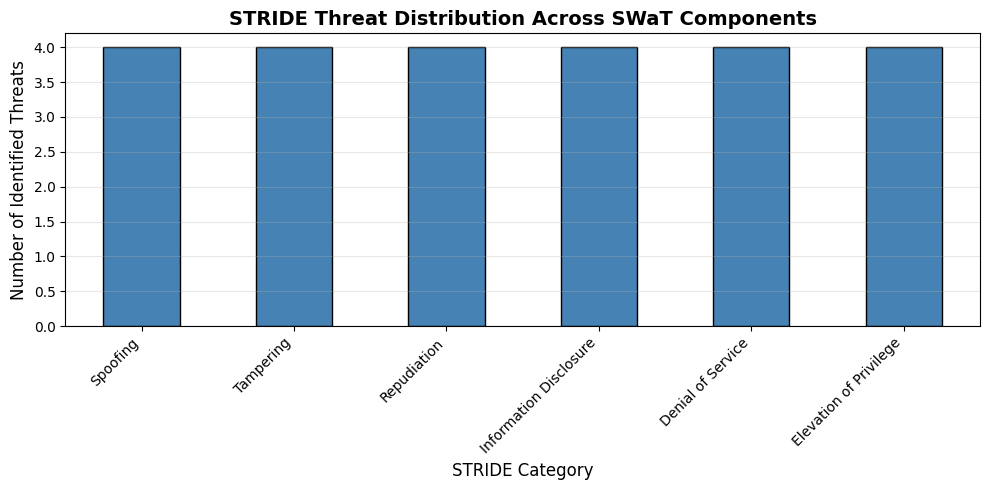

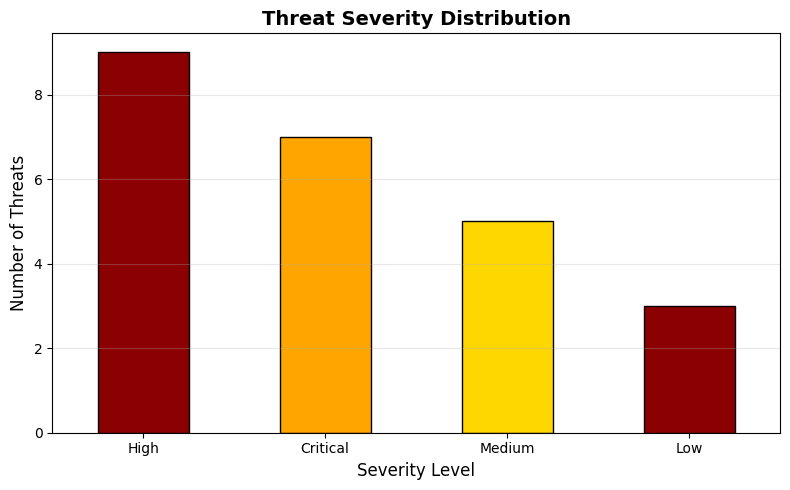

In [4]:
# Summarize STRIDE threat counts by component

import matplotlib.pyplot as plt

stride_summary = df_stride.groupby(['Component', 'STRIDE Category']).size().unstack(fill_value=0)

print("\nSTRIDE Threat Distribution by Component:")
print(stride_summary)

# Simple bar chart
stride_counts = df_stride['STRIDE Category'].value_counts()

plt.figure(figsize=(10, 5))
stride_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('STRIDE Threat Distribution Across SWaT Components', fontsize=14, fontweight='bold')
plt.xlabel('STRIDE Category', fontsize=12)
plt.ylabel('Number of Identified Threats', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Severity distribution
severity_counts = df_stride['Severity'].value_counts()

plt.figure(figsize=(8, 5))
severity_counts.plot(kind='bar', color=['darkred', 'orange', 'gold'], edgecolor='black')
plt.title('Threat Severity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Number of Threats', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.1 STRIDE Insights for SWaT

**Key Observations:**

1. **Tampering and Elevation of Privilege** are the most severe threats
   - Direct impact on control logic and process safety
   - Potential for persistent compromise

2. **Denial of Service** is critical for availability
   - CPS cannot tolerate extended downtime
   - Safety systems must remain operational

3. **Spoofing** attacks on sensors and control commands are high-risk
   - False sensor data can trigger unsafe control decisions
   - Attackers can masquerade as legitimate devices

4. **Repudiation** is less critical but important for forensics
   - Audit logs enable post-incident analysis
   - Regulatory compliance requires traceability

**Mitigation Strategy Preview:**
- Authentication mechanisms (cryptographic signatures)
- Network segmentation and access control
- Intrusion detection at protocol level
- Anomaly detection (to be developed in later notebooks)

---

## 7. Attack Trees (Conceptual)

### 7.1 What are Attack Trees?

An **attack tree** is a hierarchical model where:
- **Root node:** Attacker's ultimate goal
- **Leaf nodes:** Atomic attack steps
- **AND/OR gates:** Logical relationships between sub-goals

**Benefits:**
- Structured decomposition of complex attacks
- Identification of critical paths
- Prioritization of defenses

### 7.2 Example: Attack Tree for "Cause Water Tank Overflow"

```
Goal: Cause P1 Tank Overflow (Safety Hazard)
│
├── OR: Manipulate Water Inlet
│   ├── AND: Compromise PLC P1
│   │   ├── Exploit PLC vulnerability
│   │   └── Inject malicious ladder logic
│   ├── AND: Spoof Sensor Readings
│   │   ├── Man-in-the-middle on sensor network
│   │   └── Send false low-level readings
│   └── Physical tampering with motorized valve
│
└── OR: Disable Overflow Protection
    ├── Disable safety interlock in SCADA
    ├── AND: Compromise HMI
    │   ├── Phishing attack on operator
    │   └── Disable alarm system
    └── Physically damage overflow sensor
```

**Attack Path Analysis:**
- **Most likely path:** Compromise HMI → Disable alarms → Manipulate setpoints
- **Most stealthy path:** Spoof sensor readings (hard to detect without anomaly detection)
- **Highest impact path:** Inject persistent malicious logic into PLC

### 7.3 Using Attack Trees in This Project

In subsequent notebooks, we will:
1. **Assign probabilities** to leaf nodes based on vulnerability data
2. **Compute attack path likelihoods** using AND/OR logic
3. **Dynamically update probabilities** using LSTM-based adversarial intelligence
4. **Rank mitigation priorities** based on cost-effectiveness

In [5]:
# Represent a simplified attack tree as a nested dictionary

attack_tree = {
    'goal': 'Cause P1 Tank Overflow',
    'type': 'OR',
    'children': [
        {
            'name': 'Manipulate Water Inlet',
            'type': 'OR',
            'children': [
                {
                    'name': 'Compromise PLC P1',
                    'type': 'AND',
                    'children': [
                        {'name': 'Exploit PLC vulnerability', 'type': 'LEAF', 'base_probability': 0.15},
                        {'name': 'Inject malicious ladder logic', 'type': 'LEAF', 'base_probability': 0.20}
                    ]
                },
                {
                    'name': 'Spoof Sensor Readings',
                    'type': 'AND',
                    'children': [
                        {'name': 'MITM on sensor network', 'type': 'LEAF', 'base_probability': 0.25},
                        {'name': 'Send false low-level readings', 'type': 'LEAF', 'base_probability': 0.30}
                    ]
                },
                {'name': 'Physical tampering with valve', 'type': 'LEAF', 'base_probability': 0.05}
            ]
        },
        {
            'name': 'Disable Overflow Protection',
            'type': 'OR',
            'children': [
                {'name': 'Disable safety interlock in SCADA', 'type': 'LEAF', 'base_probability': 0.10},
                {
                    'name': 'Compromise HMI',
                    'type': 'AND',
                    'children': [
                        {'name': 'Phishing attack on operator', 'type': 'LEAF', 'base_probability': 0.40},
                        {'name': 'Disable alarm system', 'type': 'LEAF', 'base_probability': 0.35}
                    ]
                },
                {'name': 'Physically damage overflow sensor', 'type': 'LEAF', 'base_probability': 0.03}
            ]
        }
    ]
}

# Function to compute attack success probability (simplified)
def compute_attack_probability(node):
    """
    Recursively compute attack success probability.
    - AND nodes: product of child probabilities
    - OR nodes: 1 - product of (1 - child probabilities)
    - LEAF nodes: base probability
    """
    if node['type'] == 'LEAF':
        return node['base_probability']
    elif node['type'] == 'AND':
        prob = 1.0
        for child in node['children']:
            prob *= compute_attack_probability(child)
        return prob
    elif node['type'] == 'OR':
        prob = 1.0
        for child in node['children']:
            prob *= (1 - compute_attack_probability(child))
        return 1 - prob
    else:
        return 0.0

# Compute overall attack success probability
overall_prob = compute_attack_probability(attack_tree)

print(f"Attack Tree: {attack_tree['goal']}\n")
print(f"Overall Attack Success Probability (Base): {overall_prob:.4f}")
print("\nNote: This is a static baseline that can be dynamically updated")
print("using data-driven intelligence from observed system behavior.")

Attack Tree: Cause P1 Tank Overflow

Overall Attack Success Probability (Base): 0.3600

Note: This is a static baseline that can be dynamically updated
using data-driven intelligence from observed system behavior.


---

## 8. Attack Graphs (Conceptual)

### 8.1 What are Attack Graphs?

**Attack graphs** model multi-stage attacks across networked systems:
- **Nodes:** System states or network hosts
- **Edges:** Exploits or actions that transition between states
- **Paths:** Sequences of exploits leading to compromise

**Difference from Attack Trees:**
- Attack trees focus on a **single goal** hierarchically
- Attack graphs model **network-wide propagation** and lateral movement

### 8.2 Example: Attack Graph for SWaT

```
[Internet] --> [Corporate Network] --> [DMZ: HMI] --> [SCADA Server] --> [PLC P1-P6] --> [Physical Process]
      |                |                    |                 |                |
    Exploit         Phishing           Credential          Exploit         Malicious
   Firewall          Operator            Reuse            Modbus           Control
      |                |                    |                 |                |
   Initial          Foothold           Lateral            Control        Impact
   Access            Gain              Movement           Achieved
```

**Attack Graph Insights:**
- **Critical chokepoints:** SCADA server is a high-value target (centralized control)
- **Defense priorities:** Segment networks, monitor lateral movement
- **Detection opportunities:** Anomalous Modbus traffic, unusual PLC writes

### 8.3 Graph Metrics

**Shortest Path:** Minimum number of exploits to reach critical asset  
**Attack Surface:** Number of entry points (internet-facing services, USB ports)  
**Defense Coverage:** Percentage of paths with monitoring/detection  

**Future Work:**
In later notebooks, we can compute:
- Time-varying attack graph edge weights based on LSTM-detected suspicious activity
- Most probable attack paths given current system state
- Optimal sensor placement for maximum attack path coverage

---

## 9. Risk Assessment Framework

### 9.1 Risk Formula

In threat modeling, **risk** is typically expressed as:

$$
\text{Risk} = \text{Likelihood} \times \text{Impact}
$$

For CPS, we refine this to:

$$
\text{Risk} = P(\text{Threat}) \times \text{Impact}_{\text{physical}} \times \text{Detection Difficulty}
$$

Where:
- **P(Threat):** Probability of threat occurrence (from attack trees, STRIDE, or ML models)
- **Impact_physical:** Severity of physical consequences (safety, environmental, financial)
- **Detection Difficulty:** How hard it is to detect the attack (affects response time)

### 9.2 Impact Categories

| Impact Level | Description | Examples |
|--------------|-------------|----------|
| **Critical** | Loss of life, major environmental damage | Toxic chemical release, dam failure |
| **High** | Significant downtime, equipment damage | Pump burnout, process shutdown |
| **Medium** | Temporary service degradation | Quality deviation, operator alert |
| **Low** | No operational impact | Failed login attempt, information disclosure |

### 9.3 Baseline Risk Matrix

For each STRIDE threat identified earlier, we can assign a preliminary risk score.

In [6]:
# Create a risk matrix for top STRIDE threats

risk_data = {
    'Threat ID': ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8'],
    'Threat': [
        'Malicious PLC ladder logic injection',
        'Spoofed sensor readings causing unsafe control',
        'SCADA credential theft via phishing',
        'Denial of service against control network',
        'Elevation of privilege on HMI workstation',
        'Tampering with historian data',
        'Physical destruction of sensor network',
        'Information disclosure of control algorithms'
    ],
    'Component': ['PLC', 'Sensor Network', 'SCADA', 'Control Network', 'HMI', 'SCADA', 'Sensor Network', 'PLC'],
    'STRIDE': ['Tampering', 'Spoofing', 'Spoofing', 'DoS', 'Elevation', 'Tampering', 'DoS', 'Info Disclosure'],
    'Likelihood (Base)': [0.15, 0.25, 0.40, 0.20, 0.30, 0.10, 0.05, 0.12],
    'Impact': ['Critical', 'Critical', 'High', 'Critical', 'Critical', 'Medium', 'High', 'Low'],
    'Detection Difficulty': ['High', 'High', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Medium']
}

df_risk = pd.DataFrame(risk_data)

# Map impact to numeric scale
impact_map = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
detection_map = {'High': 1.5, 'Medium': 1.2, 'Low': 1.0}

df_risk['Impact_Score'] = df_risk['Impact'].map(impact_map)
df_risk['Detection_Factor'] = df_risk['Detection Difficulty'].map(detection_map)

# Compute risk score
df_risk['Risk_Score'] = df_risk['Likelihood (Base)'] * df_risk['Impact_Score'] * df_risk['Detection_Factor']

# Sort by risk
df_risk_sorted = df_risk.sort_values('Risk_Score', ascending=False)

print("Risk Assessment for Top STRIDE Threats\n")
print(df_risk_sorted[['Threat ID', 'Threat', 'STRIDE', 'Likelihood (Base)', 'Impact', 'Risk_Score']].to_string(index=False))

Risk Assessment for Top STRIDE Threats

Threat ID                                         Threat          STRIDE  Likelihood (Base)   Impact  Risk_Score
       T2 Spoofed sensor readings causing unsafe control        Spoofing               0.25 Critical       1.500
       T3            SCADA credential theft via phishing        Spoofing               0.40     High       1.440
       T5      Elevation of privilege on HMI workstation       Elevation               0.30 Critical       1.440
       T1           Malicious PLC ladder logic injection       Tampering               0.15 Critical       0.900
       T4      Denial of service against control network             DoS               0.20 Critical       0.800
       T6                  Tampering with historian data       Tampering               0.10   Medium       0.200
       T7         Physical destruction of sensor network             DoS               0.05     High       0.150
       T8   Information disclosure of control algorithms

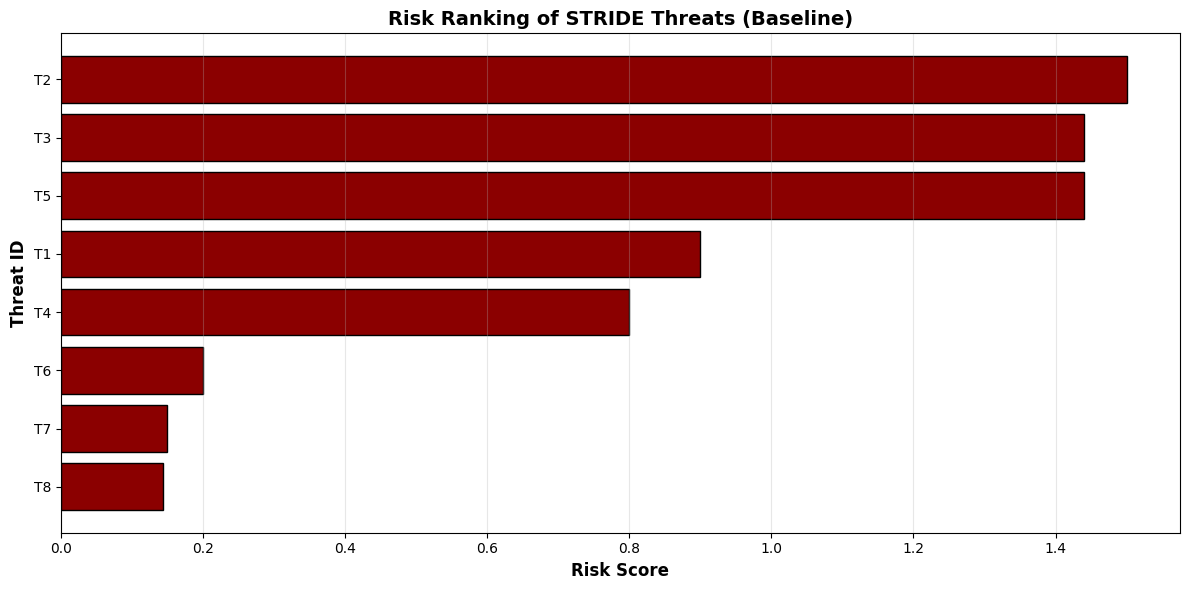


Key Insight:
These are STATIC risk scores based on design-time analysis.
These can be dynamically updated using data-driven adversarial
intelligence to reflect real-time risk in integrated systems.


In [7]:
# Visualize risk distribution

plt.figure(figsize=(12, 6))
plt.barh(df_risk_sorted['Threat ID'], df_risk_sorted['Risk_Score'], color='darkred', edgecolor='black')
plt.xlabel('Risk Score', fontsize=12, fontweight='bold')
plt.ylabel('Threat ID', fontsize=12, fontweight='bold')
plt.title('Risk Ranking of STRIDE Threats (Baseline)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("These are STATIC risk scores based on design-time analysis.")
print("These can be dynamically updated using data-driven adversarial")
print("intelligence to reflect real-time risk in integrated systems.")

---

## 10. Summary

### 10.1 What We Accomplished

In this notebook, we established the **design-time threat modeling foundation** for SWaT:

1. **CPS Architecture:** Described SWaT's layered structure (physical, cyber, communication, human)
2. **Assets and Threat Agents:** Cataloged critical assets and potential adversaries
3. **STRIDE Analysis:** Systematically identified 24 threats across key components
4. **Attack Trees:** Conceptually modeled attack goals and sub-goals
5. **Attack Graphs:** Described multi-stage attack propagation
6. **Risk Assessment:** Computed baseline risk scores for prioritization

### 10.2 Limitations of Static Threat Modeling

This design-time approach has inherent limitations:

- **Static probabilities:** Threat likelihoods are based on expert judgment, not real data
- **No temporal awareness:** Cannot detect evolving attack patterns
- **Limited context:** Does not consider current system state or historical incidents
- **Manual updates:** Requires human analysts to revise threat models

### 10.3 Role in Integrated Framework

The structured threat model built here provides **semantic scaffolding** that can be augmented with **data-driven adversarial intelligence** to create dynamic, adaptive threat assessment systems.

---

**End of Notebook 0**

In [8]:
# Save threat model artifacts for use in later notebooks

import json
import os

# Create output directory
output_dir = 'project_v0'
os.makedirs(output_dir, exist_ok=True)

# Save STRIDE threats
df_stride.to_csv(f'{output_dir}/stride_threats.csv', index=False)
print(f"✓ Saved STRIDE threats to {output_dir}/stride_threats.csv")

# Save risk assessment
df_risk_sorted.to_csv(f'{output_dir}/risk_baseline.csv', index=False)
print(f"✓ Saved baseline risk assessment to {output_dir}/risk_baseline.csv")

# Save attack tree structure
with open(f'{output_dir}/attack_tree.json', 'w') as f:
    json.dump(attack_tree, f, indent=2)
print(f"✓ Saved attack tree to {output_dir}/attack_tree.json")

# Save assets catalog
df_assets.to_csv(f'{output_dir}/assets.csv', index=False)
print(f"✓ Saved assets catalog to {output_dir}/assets.csv")

print("\nAll threat modeling artifacts saved successfully.")

✓ Saved STRIDE threats to project_v0/stride_threats.csv
✓ Saved baseline risk assessment to project_v0/risk_baseline.csv
✓ Saved attack tree to project_v0/attack_tree.json
✓ Saved assets catalog to project_v0/assets.csv

All threat modeling artifacts saved successfully.
